# **Module 3: Overview of Data Science and Machine Learning**

### **Instructor**: Dr. Hum Nath Bhandari, Department of Mathematics and Physics, RWU

### **Course**: MATH355/COMSC 415-Machine Learning

### **Quiz 3**:  Exploring Real World Regression Problems

### **Your Name:** Penn Potter

#### Abstract
The problem that I am looking at is the cost of houses based on various factors, including square footage, number of rooms, and the location of the house. This problem has real world applications, such as esitmating the price to list a house at, or seeing if a house that you are planning to buy is priced fairly. This is a real world problem that we have firm data for, as well as new data that is coming in every day, if we wanted to compare our model to real world data and see how accurate it is.

#### Best Predictors
Best inputs:
- Area
- Bathroooms
- Bedrooms
- Location

And what we should use for the prediction:
- Price

#### What Other Models Have Been Used?
 - Linear Regression
 - Random Forest


 #### Data Link

 https://drive.google.com/file/d/1QImjV5viVN-Zrjmj3cZUaG-KRzSH7JAO/view?usp=sharing

In [1]:
import os

# Ensure local folders exist
os.makedirs('./data', exist_ok=True)
os.makedirs('./results', exist_ok=True)
os.makedirs('./results/Single_DNN_Layers', exist_ok=True)
os.makedirs('./results/Multiple_DNN_Layers', exist_ok=True)
os.makedirs('./results/Hyperparameter_Tuning', exist_ok=True)


#### **Data and Results Paths**



In [2]:
data_path = "./data/"

output_dir_path = "./results/"

#### **Suppress Unnessary warnings**

In [3]:

import warnings
warnings.filterwarnings('ignore')

Head of Dataframe:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
Stats about Data:
              price          area    bedrooms   bathrooms     

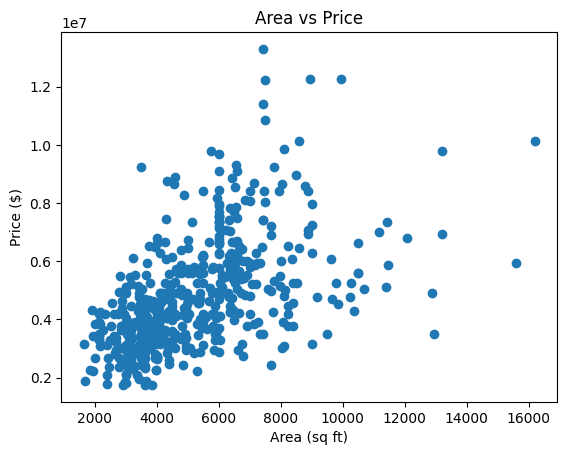

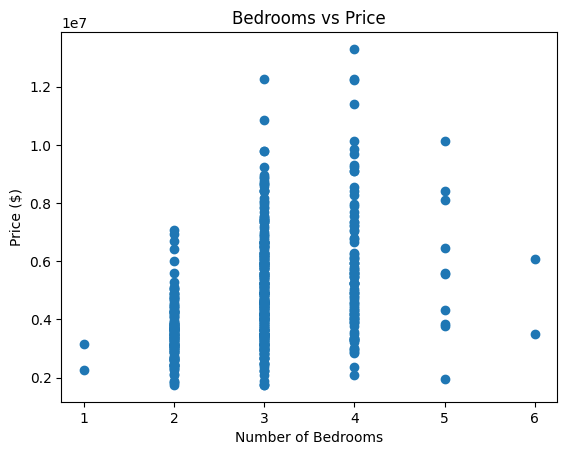

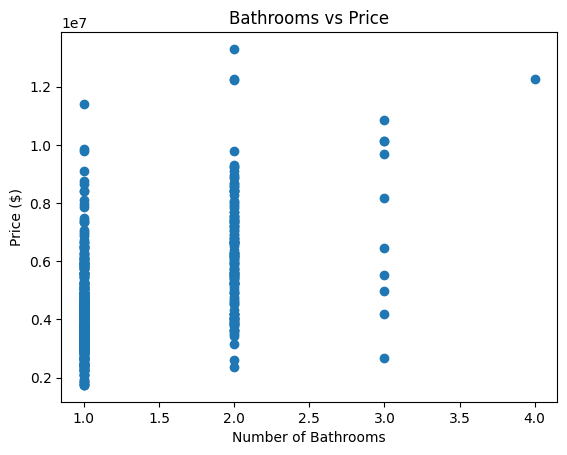

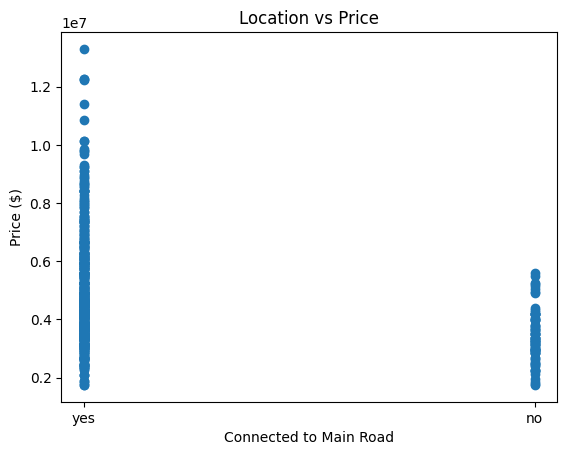

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# lead and display dataset


df = pd.read_csv(data_path + "Housing.csv")

print("Head of Dataframe:")
print(df.head())

print("Stats about Data:")
print(df.describe())

#visualize the data
plt.scatter(df['area'], df['price'])
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.title('Area vs Price')
plt.show()
#visualize the data
plt.scatter(df['bedrooms'], df['price'])
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price ($)')
plt.title('Bedrooms vs Price')
plt.show()
#visualize the data
plt.scatter(df['bathrooms'], df['price'])
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price ($)')
plt.title('Bathrooms vs Price')
plt.show()
#visualize the data
plt.scatter(df['mainroad'], df['price'])
plt.xlabel('Connected to Main Road')
plt.ylabel('Price ($)')
plt.title('Location vs Price')
plt.show()

#clean the data
df = df.dropna()

### **Step 2:  Loading, Cleaning and Exploring Data**

 - Load  **Concrete_Data.xls** data in colab
 - Display basic information about the data.
 - Handle missing values (if any).
 - Create some visualizations.
 - See relationships among variables.
 - Create correlations in heatmaps.

In [5]:

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

column_names  = ['price','area','bedrooms','bathrooms','stories', 'mainroad', 'guestroom', 'basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']


# Replace values yes/no
df = df.replace({'yes': 1, 'no': 0})

# Replace values furniture
df['furnishingstatus'] = df['furnishingstatus'].replace({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})



data=df

print(data.head())



      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3        1         0        0   
1  12250000  8960         4          4        4        1         0        0   
2  12250000  9960         3          2        2        1         0        1   
3  12215000  7500         4          2        2        1         0        1   
4  11410000  7420         4          1        2        1         1        1   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0               0               1        2        1                2  
1               0               1        3        0                2  
2               0               0        2        1                1  
3               0               1        3        1                2  
4               0               1        2        0                2  


In [6]:

print(data.info())
print(data.describe())
print(data.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.76672

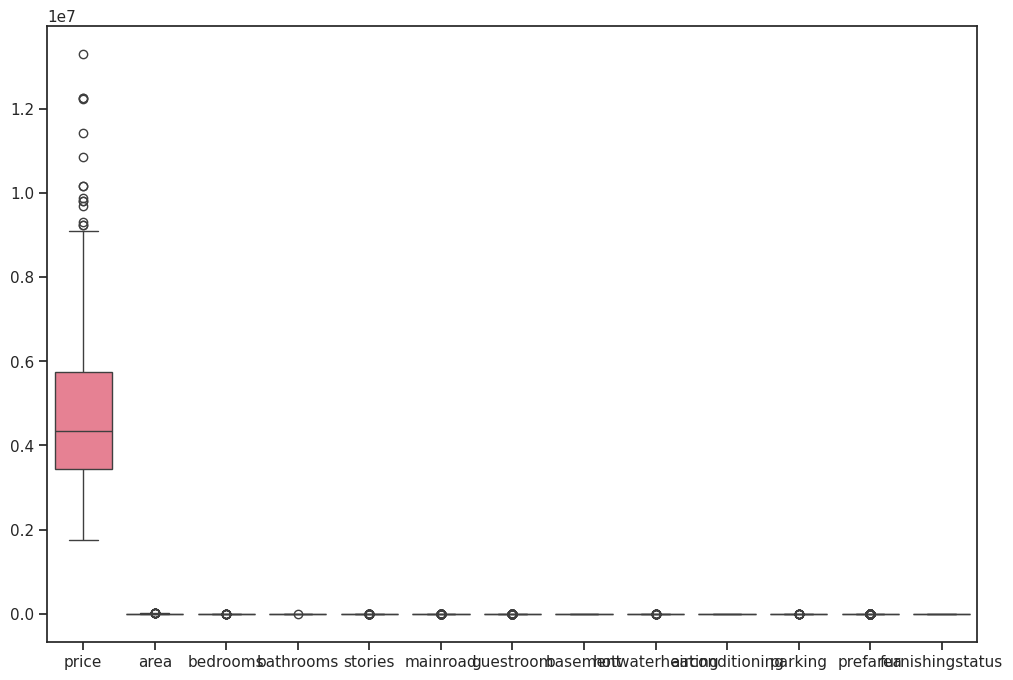

In [ ]:


fig = plt.figure(figsize= (12,8))

sns.set(style="ticks")

sns.boxplot(data = data)

fig.savefig(output_dir_path +"data_boxplots.pdf", dpi = 600)

plt.show()

fig = plt.figure(figsize= (12,8))
sns.set(style="ticks")
sns.pairplot(data = data)
fig.savefig(output_dir_path+"data_pair_plots.pdf", dpi = 600)
plt.show()


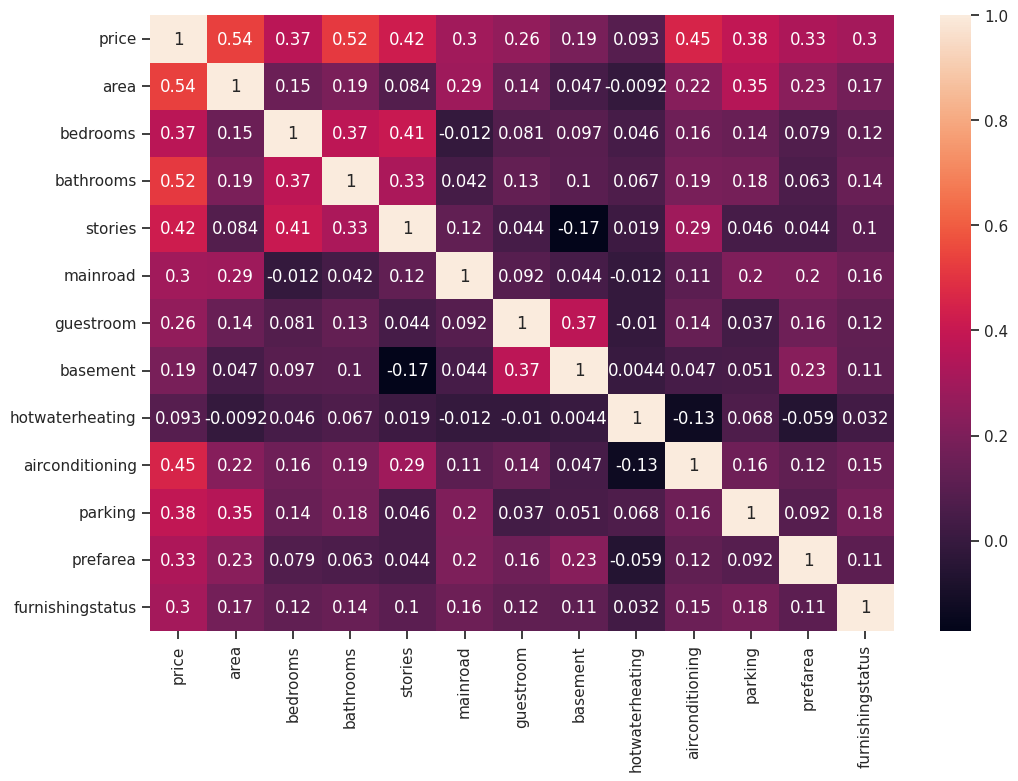

In [ ]:

fig = plt.figure(figsize = (12,8))

sns.heatmap(data.corr(), annot = True)

fig.savefig(output_dir_path+"heatmap.pdf", dpi = 600)

plt.show()




## **Step 3: Data Transformantion and Input Preparation**

 - Transform your data set if necessary.
 - Explore the transformed data.
 - Identify input features(X_data) and target variable (y_data).
 - Create training and test sets.


In [ ]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)
#use colums providid by df itself because for some reason its implying 13 not 12
data_scaled =  pd.DataFrame(data_scaled, columns = data.columns)
data_scaled.head()



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,1.000000,0.396564,0.6,0.333333,0.666667,1.0,0.0,0.0,0.0,1.0,0.666667,1.0,1.0
1,0.909091,0.502405,0.6,1.000000,1.000000,1.0,0.0,0.0,0.0,1.0,1.000000,0.0,1.0
2,0.909091,0.571134,0.4,0.333333,0.333333,1.0,0.0,1.0,0.0,0.0,0.666667,1.0,0.5
3,0.906061,0.402062,0.6,0.333333,0.333333,1.0,0.0,1.0,0.0,1.0,1.000000,1.0,1.0
4,0.836364,0.396564,0.6,0.000000,0.333333,1.0,1.0,1.0,0.0,1.0,0.666667,0.0,1.0


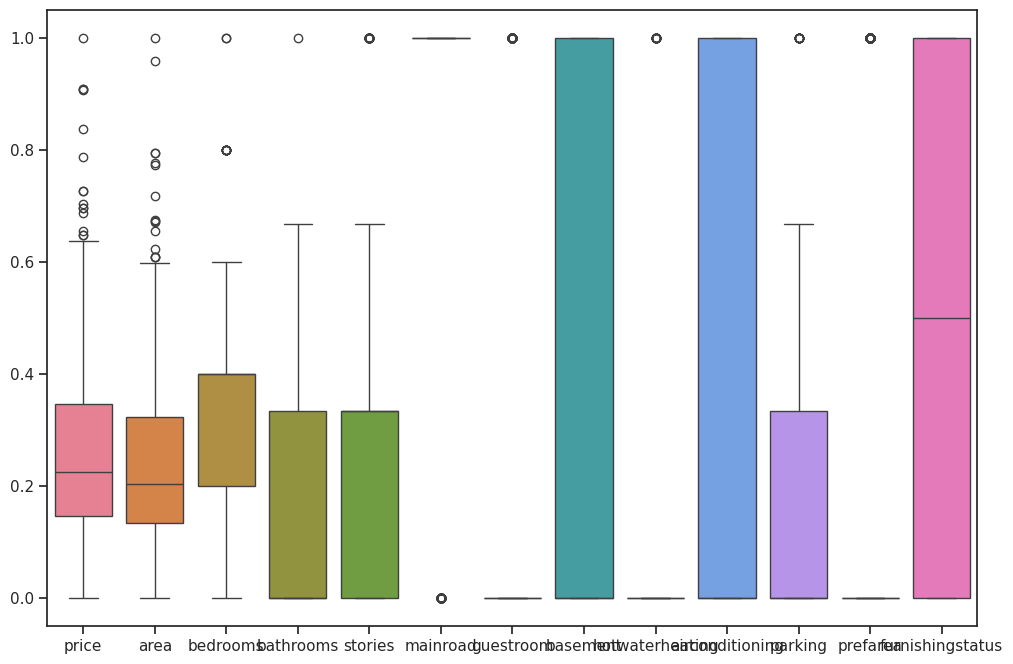

In [ ]:
fig = plt.figure(figsize= (12,8))

sns.set(style="ticks")


sns.boxplot(data = data_scaled)

fig.savefig(output_dir_path +"data_scaled_boxplots.pdf", dpi = 600)
plt.show()




In [ ]:

input_features = ['area','bathrooms','stories','airconditioning']


X_data = data_scaled[input_features]


y_data = data_scaled['price']

print("Shape of X_data", X_data.shape)
print("Shape of y_data", y_data.shape)


Shape of X_data (545, 4)
,Shape of y_data (545,)


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  =  train_test_split(X_data, y_data, test_size=0.30, random_state = 20)

print("Training Sets:",  X_train.shape, y_train.shape)
print("Test Sets: ", X_test.shape, y_test.shape)



Training Sets: (381, 4) (381,)
,Test Sets:  (164, 4) (164,)


## **Step 4: Building and Implementing Neural Networks Models**

 - Build a simple Deep Neural Network(DNN) model.
 - Display the model summary and understand how many parameters to be optimized(learned).
 - Fit the constructed model.
 - Find the predictions in test data.
 - Calculate the prediction accuracy.






### **Shuffle Training Data**

In [ ]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, shuffle=True
)

### **Build DNN Model**

In [ ]:

#Step 1: Import necessary libraries =======

from keras.models import Sequential

from keras.layers import Dense

#Step 2: Initialize Neural Network Model Configuration

#Create sequential model object
model = Sequential()

#Add first hidden layer with some neurons. Specifiy input dimension and activation function.
model.add(Dense(20, input_dim = 4, activation='relu'))

#Add second hidden layer with some neurons
model.add(Dense(10, activation='relu'))

#Add third  hidden layer with some neurons
model.add(Dense(10, activation='relu'))

#Add output layer with 1 neuron. choose activation function depending on problem.
model.add(Dense(1, activation= 'linear'))

#Compile the model with selected optimizer and loss function
model.compile(optimizer='adam', loss='mean_squared_error')

print(model.summary())


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 20)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431 (1.68 KB)

 Trainable params: 431 (1.68 KB)

 Non-trainable params: 0 (0.00 B)

None


### **Fit DNN Model**

In [ ]:
model_output = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)


### **Visualize Training History**

In [ ]:
#model_output.history['loss']


In [ ]:
#model_output.history['val_loss']

In [ ]:

def loss_plot(model_output):

  fig = plt.figure(figsize = (8,4))

  plt.plot(model_output.epoch, model_output.history['loss'], '--o', color = 'darkblue')

  plt.plot(model_output.epoch, model_output.history['val_loss'], '--o', color = 'olive')

  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss(MSE)")
  plt.legend(['Training loss', "Validation loss"],  loc= 'upper right')
  sns.set_style("whitegrid")
  fig.savefig(output_dir_path+ "train_valiation_loss_plot.png",dpi=600)



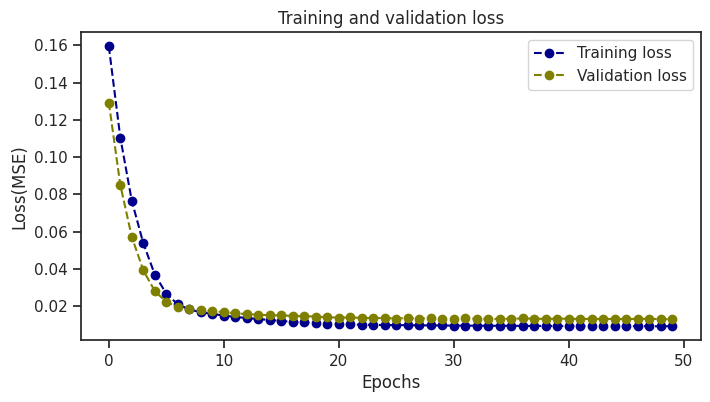

In [ ]:
loss_plot(model_output)

### **Make Predictions in Test Data**

In [ ]:
y_pred = model.predict(X_test)
#y_pred
y_pred = y_pred.ravel()
print(y_pred)




6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
,[0.32429868 0.3813823  0.49265188 0.15124846 0.37359738 0.22450483
, 0.49631232 0.256298   0.20772201 0.42252907 0.41947773 0.43068486
, 0.52243114 0.21104014 0.45252815 0.4415266  0.3398934  0.1416122
, 0.17367741 0.15818037 0.17238276 0.34285074 0.1805842  0.23395786
, 0.14244443 0.26802844 0.16914614 0.12655443 0.16745755 0.12277743
, 0.160451   0.16785148 0.20194112 0.21209668 0.19307883 0.13233909
, 0.20112409 0.39461482 0.40722716 0.16033126 0.15746765 0.1820926
, 0.12626979 0.22292557 0.34035844 0.17238276 0.34124035 0.15475255
, 0.20986296 0.47456118 0.14378878 0.16857575 0.35643545 0.1730301
, 0.2541377  0.3931036  0.13658053 0.10826001 0.22997922 0.23661031
, 0.11607892 0.14183122 0.49183866 0.44097278 0.16785148 0.14378878
, 0.2528152  0.46880326 0.1360816  0.47456118 0.14652455 0.39587995
, 0.5428501  0.27117515 0.2585265  0.47456118 0.15176812 0.21782427
, 0.5057205  0.16904236 0.12298531 0.55519724 0.2803375  0.32303798
, 0.23329529 

## Calculate Evaluation Scores

In [ ]:

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import math

import numpy as np

def calculate_scores(y_true, y_pred):
    #=====mse====
    mse = mean_squared_error(y_true, y_pred)
    #===== rmse===
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    #===== R2===
    R2_score = r2_score(y_true, y_pred)
    #===== R===
    R = np.corrcoef(y_true, y_pred)
    #===== mape===

    mape = mean_absolute_percentage_error(y_true, y_pred)

    output = {'rmse':rmse, 'R2_score': R2_score, 'R':R[0,1], 'mape': mape}
    return output


In [ ]:
test_scores = calculate_scores(y_test, y_pred)
print(test_scores) # mape value can be unreasonably high


{'rmse': 0.10985532280427579, 'R2_score': 0.5885647024245471, 'R': np.float64(0.769190488995436), 'mape': 3876780865186.898}


## **Step 5: Improving  Model Performance**

 - Remove the outliers from data.

 - Create comparative boxplots of the data with and without outliers.

 - Build and test the  model in a new data set after removing outliers.

 - Fit the model, find prediction, and accuracy scores. Compare with the previous model.

 - Visualize true vs predicted graphs of two constructed models.



In [ ]:

Q1 = data_scaled.quantile(0.25)

Q3 = data_scaled.quantile(0.75)


IQR = Q3 - Q1

print(IQR)

data_scaled_new = data_scaled[ ~((data_scaled < (Q1 - 1.5 * IQR)) | (data_scaled > (Q3 + 1.5 * IQR))).any(axis=1)]

print(data_scaled_new.shape)



price               0.200000
,area                0.189691
,bedrooms            0.200000
,bathrooms           0.333333
,stories             0.333333
,mainroad            0.000000
,guestroom           0.000000
,basement            1.000000
,hotwaterheating     0.000000
,airconditioning     1.000000
,parking             0.333333
,prefarea            0.000000
,furnishingstatus    1.000000
,dtype: float64
,(235, 13)


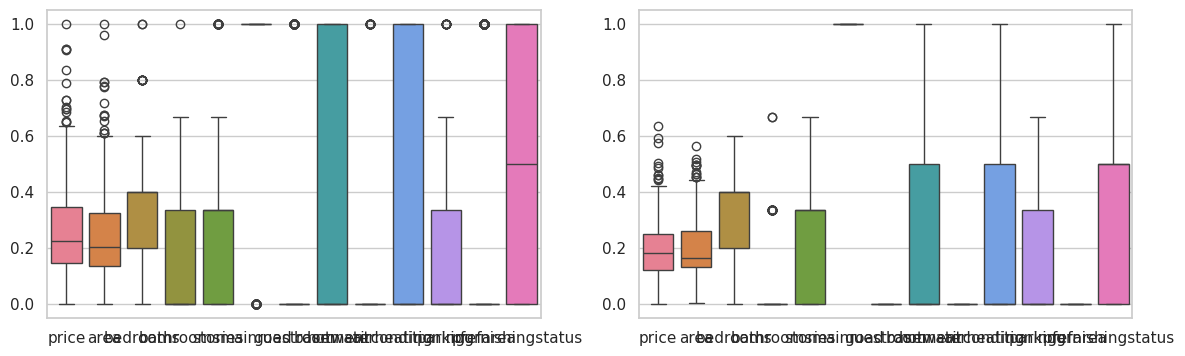

In [ ]:
fig = plt.figure(figsize= (14,4))
plt.subplot(121)
sns.boxplot(data = data_scaled)

plt.subplot(122)
sns.boxplot(data = data_scaled_new)
fig.savefig(output_dir_path +"comparative_boxplots_with_and_without_outliers.pdf", dpi = 600)
plt.show()



In [ ]:
#input_features = ['Cement','BFS','FLA','Water','SP','CA','FA','Age']

X_data_new = data_scaled_new[input_features]

y_data_new = data_scaled_new['price']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_data_new, y_data_new, test_size = 0.30, random_state=20)


In [ ]:
model2 = Sequential()

model2.add(Dense(20, input_dim = 4, activation='relu'))

model2.add(Dense(10, activation='relu'))

model2.add(Dense(10, activation='relu'))
model2.add(Dense(1, activation='linear'))
model2.compile(optimizer='adam',loss='mean_squared_error')

print(model.summary())



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 20)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295 (5.06 KB)

 Trainable params: 431 (1.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 864 (3.38 KB)

None


In [ ]:
model_output2  = model2.fit(X_train_new, y_train_new, epochs= 45, batch_size = 32, validation_split = 0.2, verbose=0)


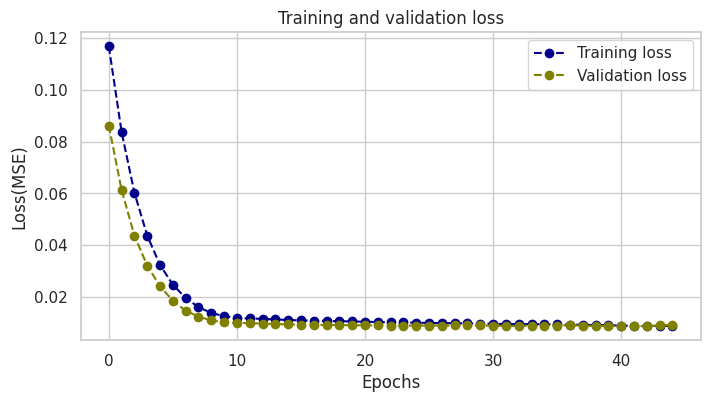

In [ ]:
loss_plot(model_output2)

In [ ]:
y_pred_new = model2.predict(X_test_new)
y_pred_new = y_pred_new.ravel()
print(y_pred_new)



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
,[0.30605245 0.15897894 0.31019163 0.20691164 0.21113315 0.15897894
, 0.23177923 0.1585578  0.15071808 0.15071808 0.20533018 0.30807918
, 0.19957845 0.2676074  0.2610611  0.18541598 0.19034101 0.15152797
, 0.3602341  0.19488081 0.2077956  0.20459746 0.2135171  0.309792
, 0.18467118 0.3057955  0.31003296 0.23704359 0.16027477 0.3092544
, 0.1839348  0.3030551  0.36214876 0.3281265  0.20484161 0.16116564
, 0.20239992 0.20033808 0.15379566 0.25342098 0.20696121 0.19034101
, 0.30928183 0.26431903 0.20256273 0.19846277 0.1651341  0.19189753
, 0.2529378  0.30213875 0.2988719  0.22636007 0.1961779  0.15379566
, 0.2144982  0.1460398  0.14642566 0.18526717 0.3495802  0.23582245
, 0.1977344  0.3092613  0.21029876 0.21037109 0.1601452  0.16027477
, 0.19563739 0.15120402 0.2778989  0.18651874 0.19926375]


In [ ]:
test_scores_new = calculate_scores(y_test_new, y_pred_new)
print(test_scores_new)


{'rmse': 0.09278790830599443, 'R2_score': 0.12574365318857228, 'R': np.float64(0.5172404711058883), 'mape': 12659456748357.092}


## **True vs Predicted Graph**

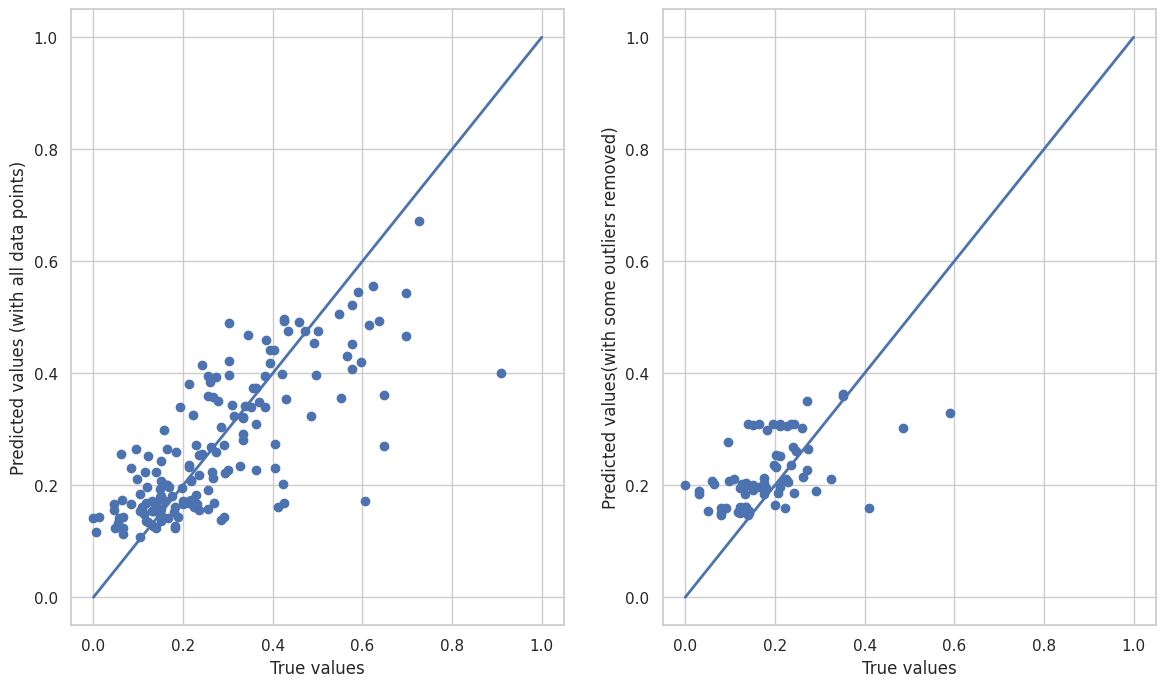

In [ ]:
fig = plt.figure(figsize= (14,8))
plt.subplot(121)
plt.scatter(y_test,y_pred)
plt.plot([0, 1], [0, 1], linewidth=2)
plt.xlabel("True values")
plt.ylabel("Predicted values (with all data points)")

plt.subplot(122)
plt.scatter(y_test_new, y_pred_new)
plt.plot([0, 1], [0, 1], linewidth=2)
plt.xlabel("True values")
plt.ylabel("Predicted values(with some outliers removed)")
fig.savefig(output_dir_path +"comparative_true_vs_predicted_values_plots.pdf", dpi = 600)


## **Step 6: More Advanced  Tasks**

- Write a function to visualize training error vs epochs.

- Write a function which can build more generic DNN models.

- Write a function which can be used for hyperparameter tuning of the models.

- Write a function which helps to train the model in a full scale with optimized hyperparameters.

- Write a function which performs results visualization.

- Write a function which perform statistical analysis.


## Advanced Tasks: Building and Implementing DNN Regressor with Varying Degree of Complexities

We will be writing the following functionalities.

1. **DNN_Regressor()**: Write a function which can build generic DNN model for Regression.

2. **Loss_Plot():** Write a function to visualize training error vs epochs.

3. **DNN_Hyperparameter_Tuning()**: Write a function which can be used for hyperparameter tuning of the models.

4. **DNN_Regressor_Implementation()**: Write a function which helps to train the model in a full scale with optimized hyperparameters.

5. **Multiple_DNN_Regressors()**: Write a function which helps to implement multiple DNN Regressors

6. **Results_Visualization()**: Write a function which performs results visualization.

7. **Statistical_Analysis()**:Write a function which perform statistical analysis.

## Build DNN Regressor¶

In [ ]:

import tensorflow as tf
from keras import  Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras import optimizers
import time
import math


In [ ]:
def write_dic_to_file(dic_name, file_name):
  file = open(file_name, 'w')
  file.write(str(dic_name))
  file.close()

import ast
def read_dic_from_file(file_name):
  file = open(file_name, "r")
  contents = file.read()
  dictionary = ast.literal_eval(contents)
  file.close()
  return dictionary


In [ ]:

def DNN_Regressor(layers, input_features, output_dim, optimizer = 'Adam', learning_rate = 0.001, verbose = 1):

  #Initialize sequential modeling architecture
  model = Sequential()

  #Add hidden layers and neurons
  for i in range(len(layers)):
    if len(layers)==1:
      model.add(Dense(layers[i], input_dim = input_features,  activation='relu'))
      model.add(Dropout(0.10))
    else:
        if i == 0:
          model.add(Dense(layers[i], input_dim = input_features,  activation='relu'))
        else:
          model.add(Dense(layers[i], activation='relu'))

        model.add(Dropout(0.10))

  #Add output layers
  model.add(Dense(output_dim, activation = 'linear')) # Neurons = 1, because we have just one continuous target to predict

  #Select optimizers and learning rates
  if optimizer == 'Adam':
    opt = optimizers.Adam(learning_rate = learning_rate)
  elif optimizer == 'Adagrad':
    opt = optimizers.Adagrad(learning_rate = learning_rate)
  elif optimizer == 'Nadam':
    opt = optimizers.Nadam(learning_rate = learning_rate)
  elif optimizer == 'Adadelta':
    opt = optimizers.Adadelta(learning_rate= learning_rate)
  elif optimizer == 'RMSprop':
    opt = optimizers.RMSprop(learning_rate= learning_rate)
  else:
    print("No optimizer found in the list(['Adam', 'Adagrad','Nadam', 'Adadelta', 'RMSprop'])! Please apply your optimizer manually...")

 # model.build(input_shape= (num_features,batch_size))

  #Compile the model
  model.compile(loss='mean_squared_error', optimizer= opt)

  if verbose == 1:
    print(model.summary())
  return model


Testing!

In [ ]:

input_features = 8
output_dim = 1

optimizers_names = ['Adam', 'Adagrad', 'Nadam']

learning_rate = 0.001
verbose = 1
layers = [10, 5, 5]


dnn_model1  = DNN_Regressor(layers, input_features, output_dim, optimizer =  optimizers_names[0], learning_rate= learning_rate, verbose = verbose)
dnn_model1


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

None


<Sequential name=sequential_15, built=True>

## Fit the DNN_Regressor()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

None
,Epoch 1/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0723 - val_loss: 0.0640
,Epoch 2/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0442 - val_loss: 0.0377
,Epoch 3/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0316 - val_loss: 0.0283
,Epoch 4/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0289 - val_loss: 0.0241
,Epoch 5/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0246 - val_loss: 0.0202
,Epoch 6/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0239 - val_loss: 0.0187
,Epoch 7/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0229 - val_loss: 0.0180
,Epoch 8/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0183 - val_loss: 0.0175
,Epoch 9/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0262 - val_loss: 0.0178
,Epoch 10/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0188 - val_loss: 0.0170
,Epoch 11/100
,19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0169 - val_loss: 0.0162
,Epoch 12/100
,19/19 ━━━━━━━━━━━━━━

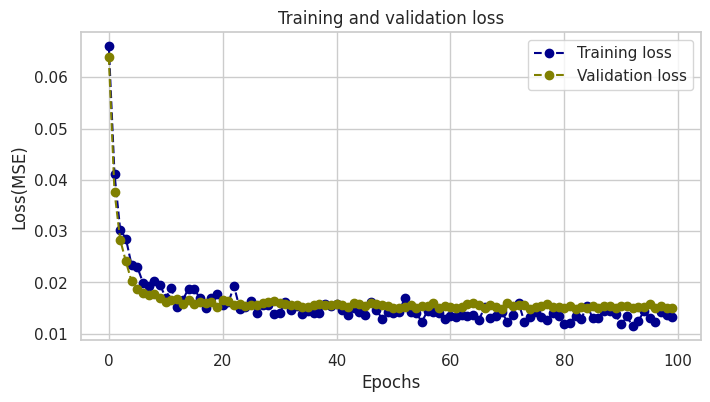

In [ ]:
input_features = 4
output_dim = 1

layers = [10, 5, 5]
optimizers_names = ['Adam', 'Adagrad', 'Nadam']
learning_rate = 0.001
batch_size =  16
epochs =  100
validation_split =  0.2 # 20% of the training data will be used for validation purpose

verbose = 1

dnn_model1  = DNN_Regressor(layers, input_features, output_dim, optimizer =  optimizers_names[0], learning_rate = learning_rate, verbose = verbose)
dnn_model1

model_output1  = dnn_model1.fit(
    X_train,
    y_train,
    epochs= epochs,
    batch_size = batch_size,
    validation_split = validation_split,
    verbose = verbose
)
loss_plot(model_output1)

## **Models Construction**

Architectures 1: Single Hidden Layer DNN Models

- Model 1: 10-DNN
- Model 2: 20-DNN
- Model 3: 50-DNN
- Model 4: 100 DNN
- Model 5: 200 DNN


Architectures 2: Multiple Hidden Layers DNN Models
- Model 6: 10-5 DNN
- Model 7: 20-10 DNN
- Model 8: 50-20 DNN
- Model 9: 100-50 DNN
- Model 10: 200-100 DNN

## **Part I: Hyperparameter Tuning**

One of the important task for any machine learning project is tuning the hyperparameters of the constructed models. In DNN, important  hyperparameters are the following.

1. Epochs
2. Optimizer
3. Learning rate
4. Bach_size


Epoch can be tuned by using the above loss_plot. We can observe the behavior of training and validation loss to understand the early stoping epoch. The particular epoch will be the best epoch to stop the training and considered as hyperparmeter.


You can combine these hyperparameters in a list:

hyperparameters = [optimizer, epochs, learning rates, batch_sizes]




##  Hyperparameter_Tuning()

In [ ]:
def DNN_Hyperparameter_Tuning(layers, input_features, output_dim, optimizers_names, learning_rates, batch_sizes, epochs, X_train, y_train, X_val, y_val, num_replicates, verbose = 1):
    best_avg_rmse = 99999999999 # start with a big number
    all_avg_rmse = np.zeros((len(optimizers_names), len(learning_rates), len(batch_sizes)))

    best_hyper_parameters = {"model": layers, "optimizer": None, "learning_rate": None, "batch_size": None, "best_avg_rmse": None}

    #you can try to record elapsed time.
    for opt in range(len(optimizers_names)):
        for lr in range(len(learning_rates)):
            for batch_size in range(len(batch_sizes)):
                collect_rmse = []

                for i in range(num_replicates):
                    print("Running for " + optimizers_names[opt] + " optimizer " + str(learning_rates[lr]) + " learning_rate " + str(batch_sizes[batch_size]) + " batch_size and " + str(i) + " replicate " + "\n")

                    model = DNN_Regressor(layers, input_features, output_dim, optimizer = optimizers_names[opt], learning_rate = learning_rates[lr], verbose = 0)

                    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

                    model.fit(
                        X_train,
                        y_train,
                        batch_size=batch_sizes[batch_size],
                        epochs=epochs,
                        validation_data=(X_val, y_val),
                        callbacks=[callback],
                        verbose=verbose,
                    )

                    #==============Making predictions in val data ==========
                    val_pred = model.predict(X_val).ravel()
                    val_scores = calculate_scores(y_val, val_pred)
                    collect_rmse.append(val_scores['rmse'])

                avg_rmse = np.mean(np.array(collect_rmse))
                all_avg_rmse[opt][lr][batch_size] = avg_rmse

                if avg_rmse < best_avg_rmse:
                    best_avg_rmse = avg_rmse
                    best_hyper_parameters = {
                        "model": layers,
                        "optimizer": optimizers_names[opt],
                        "learning_rate": learning_rates[lr],
                        "batch_size": batch_sizes[batch_size],
                        "best_avg_rmse": best_avg_rmse,
                    }

    output_dictionary = {
        "best_hyper_parameters": best_hyper_parameters,
        "all_avg_rmse": all_avg_rmse,
    }

    #writing output dictionary in the file
    file_name = output_dir_path + "dnn_regressor_" + str(layers) + "hyperparameter_tuning__results" + ".txt"
    write_dic_to_file(output_dictionary, file_name)

    print("Best_hyper_parameters(DNN) \n", output_dictionary['best_hyper_parameters'])
    print("all_avg_rmse: \n", output_dictionary['all_avg_rmse'])

    return output_dictionary['best_hyper_parameters']


In [ ]:

X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state = 20)

print("New Training Sets:",  X_train_new.shape, y_train_new.shape)
print("Validation Sets: ", X_val.shape, y_val.shape)


New Training Sets: (304, 4) (304,)
,Validation Sets:  (77, 4) (77,)


## **DNN Architecture 1- Single Layer DNN Models**

### Model 1: 10-DNN Hyperparameter Tuning

In [ ]:
output_dir_path = "results/Hyperparameter_Tuning/"
model1_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [10],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model1_best_hyperparameters

Running for Adam optimizer 0.1 learning_rate 8 batch_size and 0 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
,Running for Adam optimizer 0.1 learning_rate 8 batch_size and 1 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
,Running for Adam optimizer 0.1 learning_rate 8 batch_size and 2 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
,Running for Adam optimizer 0.1 learning_rate 8 batch_size and 3 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
,Running for Adam optimizer 0.1 learning_rate 8 batch_size and 4 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
,Running for Adam optimizer 0.1 learning_rate 16 batch_size and 0 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
,Running for Adam optimizer 0.1 learning_rate 16 batch_size and 1 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
,Running for Adam optimizer 0.1 learning_rate 16 batch_size and 2 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
,Running for Adam optimizer 0.1 learning_rate 16 batch_size an

{'model': [10],
 'optimizer': 'Adam',
 'learning_rate': 0.01,
 'batch_size': 8,
 'best_avg_rmse': np.float64(0.10760744655840629)}

## Model 2: 20-DNN Hyperparameter Tuning

In [ ]:
model2_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [20],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 50,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model2_best_hyperparameters

Running for Adam optimizer 0.1 learning_rate 8 batch_size and 0 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
,Running for Adam optimizer 0.1 learning_rate 8 batch_size and 1 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
,Running for Adam optimizer 0.1 learning_rate 8 batch_size and 2 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
,Running for Adam optimizer 0.1 learning_rate 8 batch_size and 3 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
,Running for Adam optimizer 0.1 learning_rate 8 batch_size and 4 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
,Running for Adam optimizer 0.1 learning_rate 16 batch_size and 0 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
,Running for Adam optimizer 0.1 learning_rate 16 batch_size and 1 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
,Running for Adam optimizer 0.1 learning_rate 16 batch_size and 2 replicate 
,
,3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
,Running for Adam optimizer 0.1 learning_rate 16 batch_size an

{'model': [20],
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'batch_size': 16,
 'best_avg_rmse': np.float64(0.10714273665244353)}

## Model 3: 50-DNN Hyperparameter Tuning

In [ ]:
model3_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [50],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 50,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model3_best_hyperparameters

## Model 4: 100-DNN Hyperparameter Tuning

In [ ]:
model4_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [100],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 50,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model4_best_hyperparameters

## Model 5: 200-DNN Hyperparameter Tuning

In [ ]:
model5_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [200],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 50,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model5_best_hyperparameters

## **DNN Architecture 2: Multi-Layers DNN Models**

## Model 6: 10-5-DNN Hyperparameter Tuning

In [ ]:
model6_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [10, 5],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 50,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model6_best_hyperparameters

## Model 7: 20-10-DNN Hyperparameter Tuning

In [ ]:
model7_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [20, 10],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 50,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model7_best_hyperparameters

## Model 8: 50-20-DNN Hyperparameter Tuning

In [ ]:
model8_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [50, 20],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 50,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model8_best_hyperparameters

## Model 9: 100-50-DNN Hyperparameter Tuning

In [ ]:
model9_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [100, 50],
               input_features = 4,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 50,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates = 5,
               verbose =0)

model9_best_hyperparameters

## Model 10: 200-100-DNN Hyperparameter Tuning

In [ ]:
model10_best_hyperparameters = DNN_Hyperparameter_Tuning(
                layers = [200, 100],
                input_features = 4,
                output_dim = 1,
                optimizers_names =["Adam", "Adagrad", "Adadelta"],
                learning_rates = [0.1, 0.01, 0.001],
                batch_sizes = [8, 16, 32],
                epochs = 50,
                X_train = X_train_new,
                y_train = y_train_new,
                X_val = X_val,
                y_val = y_val,
                num_replicates = 5,
                verbose =0)

model10_best_hyperparameters

## **Collecting Best Hyperparameters for Constructed Models**

In [ ]:
models  = [[10], [20],  [50], [100], [200], [10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]

best_hyper_parameters = [
    [model1_best_hyperparameters['optimizer'], model1_best_hyperparameters['learning_rate'], model1_best_hyperparameters['batch_size']],
    [model2_best_hyperparameters['optimizer'], model2_best_hyperparameters['learning_rate'], model2_best_hyperparameters['batch_size']],
    [model3_best_hyperparameters['optimizer'], model3_best_hyperparameters['learning_rate'], model3_best_hyperparameters['batch_size']],
    [model4_best_hyperparameters['optimizer'], model4_best_hyperparameters['learning_rate'], model4_best_hyperparameters['batch_size']],
    [model5_best_hyperparameters['optimizer'], model5_best_hyperparameters['learning_rate'], model5_best_hyperparameters['batch_size']],
    [model6_best_hyperparameters['optimizer'], model6_best_hyperparameters['learning_rate'], model6_best_hyperparameters['batch_size']],
    [model7_best_hyperparameters['optimizer'], model7_best_hyperparameters['learning_rate'], model7_best_hyperparameters['batch_size']],
    [model8_best_hyperparameters['optimizer'], model8_best_hyperparameters['learning_rate'], model8_best_hyperparameters['batch_size']],
    [model9_best_hyperparameters['optimizer'], model9_best_hyperparameters['learning_rate'], model9_best_hyperparameters['batch_size']],
    [model10_best_hyperparameters['optimizer'], model10_best_hyperparameters['learning_rate'], model10_best_hyperparameters['batch_size']],
]

best_hyper_parameters


## **Part II: Training DNN Regressor in Full Scale with Optimal Hyperparameters**

In [ ]:
def  DNN_Regressor_Implimentation(
               layers,
               input_features,
               output_dim,
               hyper_parameters = ['Adam', 0.01, 8], #list of hyperparameters
               X_train = None,
               y_train = None,
               X_test =  None,
               y_test =  None,
               epochs = 2,
               num_replicates = 3,
               verbose = 1):

  #============ arrays for collecting test scores ================#

  model_history = []
  train_predictions = []
  test_predictions = []

  #============ arrays for collecting test scores ================#
  #============ arrays for collecting test scores ================#
  rmse_array = np.zeros(num_replicates)
  mape_array = np.zeros(num_replicates)
  R_array    = np.zeros(num_replicates)
  elapsed_time_array = np.zeros(num_replicates)


  for i in range(num_replicates):
    print("Program is running for %d replicate ----->\n" %i)
    print('.........................Building DNN Model.......................\n')

    #Build DNN model
    model = DNN_Regressor(layers, input_features, output_dim, optimizer =  hyper_parameters[0], learning_rate= hyper_parameters[1], verbose = verbose)

    print('.........................Fitting  DNN Model.......................\n')
    start = time.time()
    callback = tf.keras.callbacks.EarlyStopping(monitor = 'loss', patience = 5)
    history = model.fit(X_train, y_train, batch_size = hyper_parameters[2], epochs = epochs, callbacks = [callback], verbose = verbose)
    end = time.time()


    #Save model history
    model_history.append(history)

    print('....................Calculating predictions...................\n')

    train_pred = model.predict(X_train).ravel()
    test_pred =  model.predict(X_test).ravel()

    train_predictions.append(train_pred)
    test_predictions.append(test_pred)


    #============== Calculating performance scores=========
    scores =   calculate_scores(y_test, test_pred)

    rmse_array[i] =  scores['rmse']
    mape_array[i] =  scores['mape']
    R_array[i] = scores['R']
    elapsed_time_array[i] = end - start

  #====Collecting results from the best performing replicate
  min_index = rmse_array.argmin()
  best_rmse = rmse_array[min_index]

  mape_with_best_rmse = mape_array[min_index]
  R_with_best_rmse =  R_array[min_index]
  elapsed_time_with_best_rmse = elapsed_time_array[min_index]

  train_predictions_with_best_rmse = train_predictions[min_index]
  test_predictions_with_best_rmse = test_predictions[min_index]
  loss_with_best_rmse = model_history[min_index].history['loss']
  #val_loss_with_best_rmse = models_history[min_index].history['val_loss']



  #Collecting important results========

  performance_metrics =  {

                        'scores': {'rmse': rmse_array,
                                    'mape': mape_array,
                                    'R': R_array,
                                    'elapsed_time': elapsed_time_array
                                    },

                        'minimums': {'rmse': np.min(rmse_array),
                                      'mape': np.min(mape_array),
                                      'R': np.min(R_array),
                                      'elapsed_time': np.min(elapsed_time_array)
                                      },

                        'avg_scores':  {'rmse': np.mean(rmse_array),
                                        'mape': np.mean(mape_array),
                                        'R': np.mean(R_array),
                                        'elapsed_time': np.mean(elapsed_time_array)
                                        },

                          'stds':      { 'rmse': np.std(rmse_array),
                                          'mape': np.std(mape_array),
                                          'R': np.std(R_array),
                                          'elapsed_time': np.std(elapsed_time_array)
                                        },

                        'maximums': {'rmse': np.max(rmse_array),
                                     'mape': np.max(mape_array),
                                     'R': np.max(R_array),
                                     'elapsed_time': np.max(elapsed_time_array)
                                     }

                  }


  model_with_best_rmse = {

                            'replicate': min_index,
                            'rmse': best_rmse,
                            #'mae': mae_with_best_rmse,
                            'mape': mape_with_best_rmse,
                            #'R2': R2_with_best_rmse,
                            'R':  R_with_best_rmse,
                            'elapsed_time': elapsed_time_with_best_rmse,
                            'train_predictions':train_predictions_with_best_rmse,
                            'test_predictions': test_predictions_with_best_rmse,
                            #'y_train':y_train_original,
                            #'y_test': y_test_original,
                            'loss':loss_with_best_rmse,
                             #'val_loss': val_loss_with_best_rmse
                            }

  #======= Collecting hyperparameters=============#
  hyper_parameters = {'layers': layers,
                        'model_specific_hyper_parameters': hyper_parameters,#additional best_hyper_parmeters for each models
                       'epochs': epochs,
                       'num_replicates': num_replicates,
                        }


  #======= Collecting all the outputs together =============#
  output_dictionary = {'hyper_parameters': hyper_parameters,
                        'performance_metrics': performance_metrics,
                         'best_model': model_with_best_rmse,
                       }


  #Save all scores in a file for statistical study
  pd.DataFrame(performance_metrics['scores']['rmse']).to_csv(output_dir_path+'DNN_Regressor-'+ str(layers)+'-rmse.csv')
  pd.DataFrame(performance_metrics['scores']['mape']).to_csv(output_dir_path+'DNN_Regressor-'+ str(layers)+'-mape.csv')
  pd.DataFrame(performance_metrics['scores']['R']).to_csv(output_dir_path+'DNN_Regressor-'+ str(layers)+'-R.csv')



  #Save data sets
  pd.DataFrame(y_train).to_csv(output_dir_path+'y_train.csv')
  pd.DataFrame(y_test).to_csv(output_dir_path+'y_test.csv')

  #Save best model results

  pd.DataFrame(model_with_best_rmse['train_predictions']).to_csv(output_dir_path+'best-DNN_Regressor-'+ str(layers)+'-train_predictions.csv')
  pd.DataFrame(model_with_best_rmse['test_predictions']).to_csv(output_dir_path +'best-DNN_Regressor-'+ str(layers)+'-test_predictions.csv')
  pd.DataFrame(model_with_best_rmse['loss']).to_csv(output_dir_path+ 'best-DNN_Regressor-'+ str(layers)+'-loss.csv')

  #model_with_best_rmse['val_loss'].to_csv(output_dir_path+'best-DNN_Regressor-model-val-loss.csv')

  #writing all statistics
  write_dic_to_file(performance_metrics,  output_dir_path + 'DNN_Regressor-'+ str(layers)+'-performance_metrics.txt')

  #writing output dictionary in the file
  file_name = output_dir_path +'DNN_Regressor-'+ str(layers)+'-full-results.txt'
  write_dic_to_file(output_dictionary, file_name)

  print("Progress: All tasks are done successfully, congratulations!!\n")
  return output_dictionary



Testing!

In [ ]:
output_dir_path = "results/"

## **Executing Multiple DNN Regressors**

In [ ]:
def Multiple_DNN_Regressors(
               model_configurations,
               hyper_parameters,
               input_features,
               output_dim,
               X_train = None,
               y_train = None,
               X_test =  None,
               y_test =  None,
               epochs = 2,
               num_replicates = 2,
               verbose = 1):

  num_models = len(model_configurations)

  #== to collect all scores===#
  rmse = []
  mape = []
  R = []
  elapsed_time = []

  #===to collect all avg scores===#
  avg_rmse = []
  avg_mape = []
  avg_R = []
  avg_elapsed_time = []

  #=== to iteratively update the best rmse and the corresponding model
  best_avg_rmse = 99999999999
  best_rmse = 99999999999
  best_model_hidden_layers = None
  best_model_output = None

  for i in range(num_models):

    print("Running model with layers neurons: \n", model_configurations[i])

    print("Best Hyper_parameters used: \n", hyper_parameters[i])

    output = DNN_Regressor_Implimentation(
                layers  = model_configurations[i],
                input_features = input_features,
                output_dim = output_dim,
                hyper_parameters =  hyper_parameters[i],
                X_train = X_train,
                y_train = y_train,
                X_test =  X_test,
                y_test = y_test,
                epochs = epochs,
                num_replicates = num_replicates,
                verbose = verbose)

    #==Collecting regressor scores
    rmse.append(output['performance_metrics']['scores']['rmse'])
    mape.append(output['performance_metrics']['scores']['mape'])
    R.append(output['performance_metrics']['scores']['R'])
    elapsed_time.append(output['performance_metrics']['scores']['elapsed_time'])

    #=== Collecting average scores
    avg_rmse.append(output['performance_metrics']['avg_scores']['rmse'])
    avg_mape.append(output['performance_metrics']['avg_scores']['mape'])
    avg_R.append(output['performance_metrics']['avg_scores']['R'])
    avg_elapsed_time.append(output['performance_metrics']['avg_scores']['elapsed_time'])

    #=== Identifying best performing model configuration
    if avg_rmse[i] < best_avg_rmse:
      best_avg_rmse = avg_rmse[i]
      best_rmse = output['best_model']['rmse']
      best_model_configuration = model_configurations[i]
      best_model_output = output

  rmse = np.array(rmse)
  mape = np.array(mape)
  R =  np.array(R)


  # ===== Collecting all  scores================================#

  performance_metrics = {

       'scores':  { 'model_configurations': model_configurations,
                   'rmse': rmse,
                   'mape': mape,
                   'R':R,
                   'elapsed_time': elapsed_time },

       'avg_scores':  pd.DataFrame({'model_configurations': model_configurations,
                                    'rmse': np.array(avg_rmse),
                                    'mape': np.array(avg_mape), 'R':np.array(avg_R),
                                    'elapsed_time':np.array(avg_elapsed_time)}),

       'stds':     pd.DataFrame({'model_configurations': model_configurations,
                                 'rmse': np.std(rmse, axis = 1),
                                 'mape': np.std(mape, axis = 1),
                                 'R':  np.std(R, axis = 1 ),
                                 'elapsed_time': np.std(elapsed_time, axis = 1 )}),
       'minimums': pd.DataFrame({'model_configurations': model_configurations,
                                'rmse': np.min(rmse, axis =1 ),
                                'mape': np.min(mape, axis= 1),
                                'R': np.min(R, axis =1),
                                'elapsed_time': np.min(elapsed_time, axis =1)}),

       'maximums': pd.DataFrame({'model_configurations': model_configurations,
                                'rmse': np.max(rmse, axis =1),
                                'mape': np.max(mape, axis =1),
                                'R': np.max(R, axis =1),
                                'elapsed_time': np.max(elapsed_time,axis =1)})
    }


  output_dictionary = {
                     'hyper_parameters': hyper_parameters,

                      'best_avg_rmse': best_avg_rmse,
                      'best_rmse': best_rmse,
                      'best_model_configuration': best_model_configuration,
                      'best_model_output': best_model_output
                      }

  #Save all statistics:
  performance_metrics['avg_scores'].to_csv(output_dir_path+'multiple_DNN_Regressor_models_average_scores.csv')
  performance_metrics['stds'].to_csv(output_dir_path+'multiple_DNN_Regressor_models_stds.csv')
  performance_metrics['minimums'].to_csv(output_dir_path+'multiple_DNN_Regressor_models_minimums.csv')
  performance_metrics['maximums'].to_csv(output_dir_path+'multiple_DNN_Regressor_models_maximums.csv')


  #Save all scores in the file for future analysis
  pd.DataFrame(performance_metrics['scores']['rmse']).to_csv(output_dir_path+'multiple_DNN_Regressor_models_all_rmse.csv')
  pd.DataFrame(performance_metrics['scores']['mape']).to_csv(output_dir_path+'multiple_DNN_Regressor_models_all_mape.csv')
  pd.DataFrame(performance_metrics['scores']['R']).to_csv(output_dir_path+'multiple_DNN_Regressor_models_all_R.csv')

  #Save best model results
  pd.DataFrame(best_model_output['best_model']['loss']).to_csv(output_dir_path+'best_DNN_Regressor_model_loss.csv')
  pd.DataFrame(best_model_output['best_model']['train_predictions']).to_csv(output_dir_path+'best_DNN_Regressor_model_train_predictions.csv')
  pd.DataFrame(best_model_output['best_model']['test_predictions']).to_csv(output_dir_path+'best_DNN_Regressor_model_test_predictions.csv')
  pd.DataFrame(best_model_output['performance_metrics']['scores']['rmse']).to_csv(output_dir_path+'best_DNN_Regressor_model_all_rmse.csv')

  #writing all result in the file
  write_dic_to_file(output_dictionary, output_dir_path + "multiple_DNN_Regressor_models_full_results.txt")

  #Display some key results in the screen
  print("\nBest model and its avg rmse and minimum rmse):\n", best_model_configuration, best_avg_rmse, best_rmse)
  print("Hyper_parameters:\n", hyper_parameters)
  print('\nAverage scores:\n',  performance_metrics['avg_scores'])
  print('\nStandard_deviations:\n',  performance_metrics['stds'])
  print('\nMinimums:\n',  performance_metrics['minimums'])
  print('\nMaximums:\n',  performance_metrics['maximums'])
  print("Progress: All works are done successfully, congratulations!!\n")




## **Step 1: Running Single Layer DNN Models**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.30, random_state=20)

print("Training Sets:",  X_train.shape, y_train.shape)
print("Test Sets: ", X_test.shape, y_test.shape)



In [ ]:

model_configurations  = [[10], [20],  [50], [100], [200]]

model_configurations  = [[10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]


best_hyper_parameters   = [
                             ['Adagrad', 0.001, 8], #Model 1: 10-DNN
                             ['Adagrad', 0.001, 8], #Model 2: 20-DNN
                             ['Adagrad', 0.001, 8], #Model 3: 50-DNN
                             ['Adagrad', 0.001, 8], #Model 4: 100-DNN
                            ['Adagrad', 0.1, 8],  #Model 5: 200-DNN
                           #['Adagrad', 0.1, 8], #Model 6: 10-5-DNN
                           #['Adagrad', 0.1, 8], #Model 7: 20-10-DNN
                           #['Adagrad', 0.1, 8], #Model 8: 50-20-DNN
                           #['Adagrad', 0.1, 8], #Model 9: 100-50-DNN
                            #['Adagrad', 0.1, 8], #Model 10: 200-100-DNN
                        ]


output_dir_path =  "results/Single_DNN_Layers/"


Multiple_DNN_Regressors(
               model_configurations = model_configurations,
               hyper_parameters = best_hyper_parameters,
               input_features = 4,
               output_dim = 1,
               X_train = X_train,
               y_train = y_train,
               X_test =  X_test,
               y_test =  y_test,
               epochs = 10,
               num_replicates = 10,
               verbose = 1)
best_hyper_parameters   = [
                             ['Adagrad', 0.001, 8], #Model 1: 10-DNN
                             ['Adagrad', 0.001, 8], #Model 2: 20-DNN
                             ['Adagrad', 0.001, 8], #Model 3: 50-DNN
                            ['Adagrad', 0.001, 8], #Model 4: 100-DNN
                            ['Adagrad', 0.1, 8] #Model 5: 200-DNN
                           #['Adagrad', 0.1, 8], #Model 6: 10-5-DNN
                           #['Adagrad', 0.1, 8], #Model 7: 20-10-DNN
                           #['Adagrad', 0.1, 8], #Model 8: 50-20-DNN
                           #['Adagrad', 0.1, 8], #Model 9: 100-50-DNN
                            #['Adagrad', 0.1, 8], #Model 10: 200-100-DNN
                        ]

## **Step 2: Running Multi-Layer DNN Models**

In [ ]:
model_configurations  = [[10], [20],  [50], [100], [200]]

model_configurations  = [[10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]


best_hyper_parameters   = [
                             #['Adagrad', 0.001, 8], #Model 1: 10-DNN
                             #['Adagrad', 0.001, 8], #Model 2: 20-DNN
                             #['Adagrad', 0.001, 8], #Model 3: 50-DNN
                            #['Adagrad', 0.001, 8], #Model 4: 100-DNN
                            #['Adagrad', 0.1, 8] #Model 5: 200-DNN
                           ['Adagrad', 0.01, 8], #Model 6: 10-5-DNN
                           ['Adagrad', 0.01, 8], #Model 7: 20-10-DNN
                           ['Adagrad', 0.01, 8], #Model 8: 50-20-DNN
                           ['Adagrad', 0.01, 8], #Model 9: 100-50-DNN
                            ['Adagrad', 0.01, 8] #Model 10: 200-100-DNN
                        ]

output_dir_path =  "./results/Multiple_DNN_Layers/"


Multiple_DNN_Regressors(
               model_configurations = model_configurations,
               hyper_parameters = best_hyper_parameters,
               input_features = 4,
               output_dim = 1,
               X_train = X_train,
               y_train = y_train,
               X_test =  X_test,
               y_test =  y_test,
               epochs = 10,
               num_replicates = 10,
               verbose = 1)

# **Part III:  Results Visualization**

## Setup file paths

In [ ]:
path1 =  "./results/Single_DNN_Layers/"

path2 = "./results/Multiple_DNN_Layers/"

output_dir_path = "./results/"

## **Plot 1: Loss plot of the best Single and Multi Layer DNN**

In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

def loss_plot(loss1, loss2, fig_name):

  fig = plt.figure(figsize = (6,4))

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 1
  plt.rc('xtick',labelsize=12)
  plt.rc('ytick',labelsize=12)
  plt.rcParams["axes.labelweight"] = "bold"

  colors = ['purple', 'mediumblue']

  plt.plot(loss1 , '--o',  linewidth = 2.5, color = colors[0])
  plt.plot(loss2, '--o',  linewidth = 2.5, color = colors[1])
#what are we trying to plot???
#  plt.plot(cnn_loss, '--o',  linewidth = 1.5, color = colors[2])

  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend(['Single DNN Layer', 'Multi_DNN Layer'],  loc = 'upper right')
  plt.rcParams['axes.facecolor']='w'
  plt.grid(color='#F5F5DC')

  fig.savefig(fig_name,dpi=600)



In [ ]:

best_loss1 = pd.read_csv(path1+'best_DNN_Regressor_model_loss.csv')
best_loss2 = pd.read_csv(path2+'best_DNN_Regressor_model_loss.csv')

loss_plot(best_loss1.iloc[:, 1], best_loss2.iloc[:, 1], output_dir_path +"loss_plot.pdf")




##  **Plot 2: Average Scores Plot**

In [ ]:

def avg_test_scores_plot(configuration1, configuration2, avg_scores1, avg_scores2, fig_name):

  sns.set_theme(style = "whitegrid")
  plt.rc('font', weight='bold')

  fig = plt.figure(figsize = (16, 5)) #(22,5)

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 1
  plt.rc('xtick',labelsize=12)
  plt.rc('ytick',labelsize=12)
  plt.rcParams["axes.labelweight"] = "bold"

  plt.subplot(121)
  plt.plot(avg_scores1['model_configurations'], avg_scores1['rmse'], '-o', linewidth = 2.5, color = 'y')
  plt.plot(avg_scores1['model_configurations'], avg_scores1['R'], '-o', linewidth = 2.5, color = 'c')
  plt.plot(avg_scores1['model_configurations'], avg_scores1['mape'], '-o', linewidth = 2.5, color = 'red')
  plt.xticks([0, 1,2,3,4],configuration1, fontsize = 8,  rotation=30)

  plt.title("Single Layer DNN Model Configurations", fontsize = 10)
  plt.ylabel("Performance scores", fontsize = 10)
  plt.legend(['RMSE', 'R'],  loc = 'best')
  plt.legend(['RMSE', 'R' , 'MAPE'],  loc = 'best')

  plt.subplot(122)
  plt.plot(avg_scores2['model_configurations'], avg_scores2['rmse'], '-o', linewidth = 2.5, color = 'y')
  plt.plot(avg_scores2['model_configurations'], avg_scores2['R'], '-o', linewidth = 2.5, color = 'c')
  plt.plot(avg_scores2['model_configurations'], avg_scores2['mape'], '-o', linewidth = 2.5, color = 'red')
  plt.xticks([0, 1,2,3,4], configuration2, fontsize = 8,  rotation=30)
  plt.title("Accuracy")
  plt.title("Multi Layers DNN Model Configurations", fontsize = 10)
  plt.ylabel("Performance scores", fontsize = 10)
  plt.legend(['RMSE', 'R'],  loc = 'best')
  plt.legend(['RMSE', 'R' , 'MAPE'],  loc = 'best')

  fig.savefig(fig_name,dpi=600)
  plt.show()




In [ ]:
avg_scores1 = pd.read_csv(path1+'multiple_DNN_Regressor_models_average_scores.csv')
avg_scores2 = pd.read_csv(path2+'multiple_DNN_Regressor_models_average_scores.csv')

single_dnn_configurations = ['M1:10-DNN', 'M2:20-DNN', 'M3:50-DNN', 'M4:100-DNN', 'M5:200-CNN']
multi_dnn_configurations = ['M6:10-5-DNN', 'M7:20-10-DNN', 'M8:50-20-DNN', 'M9:100-50-DNN', 'M10:200-100-DNN']

avg_test_scores_plot(single_dnn_configurations, multi_dnn_configurations, avg_scores1, avg_scores2, output_dir_path+ "multiple_avg_scores_plots.pdf")



## **Plot 3: True Vs Predicted Plots**



In [ ]:
def best_model_true_vs_prediction_plot(y_train, y_test, single_dnn_train_pred, single_dnn_test_pred, multi_dnn_train_pred, multi_dnn_test_pred):

  ##====== Visualizing true vs predicted plots ========#
  fig1 = plt.figure(figsize= (12,4))
  plt.subplot(121)

  plt.scatter(y_train, single_dnn_train_pred, marker = "+" , color ='mediumblue')
  identity_line = np.linspace(max(min(y_train), min(single_dnn_train_pred)), min(max(y_train), max(single_dnn_train_pred)))
  plt.plot(identity_line, identity_line, color="red", linestyle="dashed", linewidth=2.5)

  plt.xlabel("True")
  plt.ylabel("Predicted")
  plt.title("Single DNN")

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 2.75
  plt.rc('xtick',labelsize=10)
  plt.rc('ytick',labelsize=10)


  plt.subplot(122)
  plt.scatter(y_train, multi_dnn_train_pred, marker = "+" , color ='mediumblue' )
  identity_line = np.linspace(max(min(y_train), min(multi_dnn_train_pred)), min(max(y_train), max(multi_dnn_train_pred)))
  plt.plot(identity_line, identity_line, color="red", linestyle="dashed", linewidth=2.5)

  plt.xlabel("True")
  plt.ylabel("Predicted")
  plt.title("Single DNN")

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 2.75
  plt.rc('xtick',labelsize=10)
  plt.rc('ytick',labelsize=10)


  fig1.savefig(output_dir_path+"true_vs_prediction_plot_train_data.pdf", dpi=600)

  ##====== Visualizing true vs predicted plots ========#
  fig2 = plt.figure(figsize= (12,4))
  plt.subplot(121)
  plt.scatter(y_test, single_dnn_test_pred, marker = "+" , color ='mediumblue')
  identity_line = np.linspace(max(min(y_test), min(single_dnn_test_pred)), min(max(y_test), max(single_dnn_test_pred)))
  plt.plot(identity_line, identity_line, color= "red", linestyle="dashed", linewidth=2.5)
  plt.xlabel("True")
  plt.ylabel("Predicted")
  plt.title("Single DNN Models")

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 2.75
  plt.rc('xtick',labelsize=10)
  plt.rc('ytick',labelsize=10)

  plt.subplot(122)
  plt.scatter(y_test, multi_dnn_test_pred, marker = "+" , color ='mediumblue' )
  identity_line = np.linspace(max(min(y_test), min(multi_dnn_test_pred)), min(max(y_test), max(multi_dnn_test_pred)))
  plt.plot(identity_line, identity_line, color="red", linestyle="dashed", linewidth=2.5)
  plt.xlabel("True")
  plt.ylabel("Predicted")
  plt.title("Multi Layer DNN")

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 2.75
  plt.rc('xtick',labelsize=10)
  plt.rc('ytick',labelsize=10)


  fig2.savefig(output_dir_path+ "true_vs_prediction_plot_test_data.png", dpi=600)
  plt.show()



In [ ]:
#tru vs  predicted

y_train = pd.read_csv(path1+ 'y_train.csv')
y_test =  pd.read_csv(path1+ 'y_test.csv')

best_single_dnn_train_pred = pd.read_csv(path1+ 'best_DNN_Regressor_model_train_predictions.csv')
best_single_dnn_test_pred = pd.read_csv(path1+ 'best_DNN_Regressor_model_test_predictions.csv')

best_multi_dnn_train_pred = pd.read_csv(path2+ 'best_DNN_Regressor_model_train_predictions.csv')
best_multi_dnn_test_pred = pd.read_csv(path2+ 'best_DNN_Regressor_model_test_predictions.csv')



best_model_true_vs_prediction_plot(y_train.iloc[:,1],
                                   y_test.iloc[:,1],
                                   best_single_dnn_train_pred.iloc[:,1],
                                   best_single_dnn_test_pred.iloc[:,1],
                                   best_multi_dnn_train_pred.iloc[:,1],
                                   best_multi_dnn_test_pred.iloc[:,1])



## **Plot 4: All score boxplots**



In [ ]:

def all_scores_boxplot(config, rmse, R, mape, fig_name):

  sns.set_theme(style = "whitegrid")
  plt.rc('font', weight='bold')

  fig = plt.figure(figsize = (18,5))

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 1
  plt.rc('xtick',labelsize=12)
  plt.rc('ytick',labelsize=12)
  plt.rcParams["axes.labelweight"] = "bold"

  plt.subplot(131)
  p1 = plt.boxplot(rmse, patch_artist=True)
  for i, box in enumerate(p1['boxes']):
    # change outline color
    box.set(color= 'blue', linewidth = 1.2)
    # change fill color
    box.set(facecolor = 'cyan')
  plt.xticks([])
  plt.xticks([1,2,3,4,5], config,fontsize = 8, rotation = 30 )
  plt.title('', fontweight='bold')
  plt.ylabel('RMSE')


  plt.subplot(132)
  p2 = plt.boxplot(R, patch_artist=True)
  for i, box in enumerate(p2['boxes']):
    # change outline color
    box.set(color= 'blue', linewidth = 1.2)
    # change fill color
    box.set(facecolor = 'slateblue')
  plt.xticks([])
  plt.xticks([1,2,3,4,5], config, fontsize = 8, rotation = 30 )
  plt.title('', fontweight='bold')
  plt.ylabel('R')


  plt.subplot(133)
  p3 = plt.boxplot(mape, patch_artist=True)
  for i, box in enumerate(p3['boxes']):
    # change outline color
    box.set(color= 'blue', linewidth = 1.2)
    # change fill color
    box.set(facecolor = 'violet')
  plt.xticks([ 1,2,3,4,5], config,fontsize = 8, rotation = 30 )
  plt.title('', fontweight='bold')
  plt.ylabel('MAPE')
  fig.savefig(fig_name, dpi=600)
  plt.show()




In [ ]:
single_dnn_rmse = pd.read_csv(path1+'multiple_DNN_Regressor_models_all_rmse.csv')
single_dnn_R = pd.read_csv(path1+'multiple_DNN_Regressor_models_all_R.csv')
single_dnn_mape = pd.read_csv(path1+'multiple_DNN_Regressor_models_all_mape.csv')

multi_dnn_rmse = pd.read_csv(path2+'multiple_DNN_Regressor_models_all_rmse.csv')
multi_dnn_R = pd.read_csv(path2+'multiple_DNN_Regressor_models_all_R.csv')
multi_dnn_mape = pd.read_csv(path2+'multiple_DNN_Regressor_models_all_mape.csv')


single_dnn_configurations = ['M1:10-DNN', 'M2:20-DNN', 'M3:50-DNN', 'M4:100-DNN', 'M5:200-CNN']
multi_dnn_configurations = ['M6:10-5-DNN', 'M7:20-10-DNN', 'M8:50-20-DNN', 'M9:100-50-DNN', 'M10:200-100-DNN']

all_scores_boxplot(single_dnn_configurations, single_dnn_rmse.iloc[:, 1:].T, single_dnn_R.iloc[:, 1:].T,  single_dnn_mape.iloc[:, 1:].T, output_dir_path+ "single_DNN_all_scores_boxplots.pdf")

all_scores_boxplot(multi_dnn_configurations , multi_dnn_rmse.iloc[:, 1:].T, multi_dnn_R.iloc[:, 1:].T,  multi_dnn_mape.iloc[:, 1:].T,  output_dir_path+ "multi_DNN_all_scores_boxplots.pdf")


## **Plot 5: Performing Statistical Analysis**

In [ ]:
def comparative_qq_plots(data1, data2, fig_name):
  fig = plt.figure(figsize = (12,5))

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 1
  plt.rc('xtick',labelsize=12)
  plt.rc('ytick',labelsize=12)
  plt.rcParams["axes.labelweight"] = "bold"


  ax1= fig.add_subplot(121)
  scipy.stats.probplot(data1, dist=scipy.stats.norm, sparams=(0,1), plot=ax1)
  ax1.get_lines()[0].set_marker('o')
  ax1.get_lines()[0].set_markerfacecolor('mediumblue')
  ax1.get_lines()[0].set_markersize(8.0)
  ax1.get_lines()[1].set_linewidth(3.0)
  plt.title("Single Layer DNN", fontweight='bold')


  ax2= fig.add_subplot(122)
  scipy.stats.probplot(data2, dist=scipy.stats.norm, sparams=(0,1), plot=ax2)
  ax2.get_lines()[0].set_marker('o')
  ax2.get_lines()[0].set_markerfacecolor('mediumblue')
  ax2.get_lines()[0].set_markersize(8.0)
  ax2.get_lines()[1].set_linewidth(3.0)
  plt.title("Multi Layers DNN ", fontweight='bold')

  fig.savefig(fig_name,dpi=600)
  plt.show()



import scipy

def perform_normality_test(sample1, sample2):
  print("Performaing Normality Tests\n")
  print("Single_layer_dnn_rmse: ")
  print(scipy.stats.normaltest(sample1))
  print("multi_layers_dnn_rmse:")
  print(scipy.stats.normaltest(sample2))

def perform_pairwise_ttests(sample1, sample2):
  print("\n Two-sample ttest between sample 1 and sample 2")
  print(scipy.stats.ttest_ind(sample1, sample2, equal_var = False))  # It does not require variences to be equal.



In [ ]:

best_single_layer_dnn_rmse = pd.read_csv(path1+ 'best_DNN_Regressor_model_all_rmse.csv')
best_multi_layers_dnn_rmse = pd.read_csv(path2+ 'best_DNN_Regressor_model_all_rmse.csv')



In [ ]:
fig_name = output_dir_path+ "best_model_rmse_qq_plots.pdf"


print("===========Visualizing qq plots ======================\n")
comparative_qq_plots(best_single_layer_dnn_rmse.iloc[:,1],best_multi_layers_dnn_rmse .iloc[:,1], fig_name)


print("===========Performing Normality Ttest:======================\n")
perform_normality_test(best_single_layer_dnn_rmse.iloc[:,1],best_multi_layers_dnn_rmse.iloc[:,1])

print("===========Performing Ttest:======================\n")
perform_pairwise_ttests(best_single_layer_dnn_rmse.iloc[:,1],best_multi_layers_dnn_rmse.iloc[:,1])

